# Setup

In [48]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("../.env")
sys.path.insert(0, str(Path.cwd().parent))

from scripts.download_data import download_data
from scripts.parse_small_csv import load_data

FILE_URL = os.environ['SMALL_CSV_FILE_URL']
FILE_NAME = os.environ['SMALL_CSV_FILE_NAME']
DATA_DIR = os.environ["DATA_DIR_PATH"]

csv_path = download_data(url=FILE_URL, filename=FILE_NAME, target_path=DATA_DIR)
df = load_data(csv_path)
df.head()

Skipping download. Data already exists /Users/mf16331x/Shopee AI Engineer Technical Test/src/1-csv-parsing/data/customer-100000.csv


,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,Sanchez-Fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/
1,2,b687FfC4F1600eC,Marie,Malone,Mckay PLC,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,Marks and Sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"Kirby, Vaughn and Sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,Lester-Manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/


# Dataset Overview

## Data type

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Index              100000 non-null  int64
 1   Customer Id        100000 non-null  str  
 2   First Name         100000 non-null  str  
 3   Last Name          100000 non-null  str  
 4   Company            100000 non-null  str  
 5   City               100000 non-null  str  
 6   Country            100000 non-null  str  
 7   Phone 1            100000 non-null  str  
 8   Phone 2            100000 non-null  str  
 9   Email              100000 non-null  str  
 10  Subscription Date  100000 non-null  str  
 11  Website            100000 non-null  str  
dtypes: int64(1), str(11)
memory usage: 9.2 MB


In [50]:
display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "unique": df.nunique()
    })
)

,column,dtype,non_null,missing,unique
Index,Index,int64,100000,0,100000
Customer Id,Customer Id,str,100000,0,100000
First Name,First Name,str,100000,0,690
Last Name,Last Name,str,100000,0,1000
Company,Company,str,100000,0,71994
City,City,str,100000,0,49154
Country,Country,str,100000,0,243
Phone 1,Phone 1,str,100000,0,100000
Phone 2,Phone 2,str,100000,0,100000
Email,Email,str,100000,0,99995


## Missing values

In [51]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_percentage"] = (
    missing["missing_count"] / len(df) * 100
).round(2)

display(missing)

,missing_count,missing_percentage
Index,0,0.0
Customer Id,0,0.0
First Name,0,0.0
Last Name,0,0.0
Company,0,0.0
City,0,0.0
Country,0,0.0
Phone 1,0,0.0
Phone 2,0,0.0
Email,0,0.0


## Duplicate Rows

In [52]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


# Customer Distribution

In [53]:
country_counts = (
    df["Country"]
    .value_counts()
    .head(10)
)

display(country_counts.to_frame("customer_count"))

,customer_count
Country,
Congo,835
Korea,820
Saudi Arabia,463
Pitcairn Islands,456
Saint Martin,453
Paraguay,445
Canada,444
American Samoa,443
Saint Kitts and Nevis,443


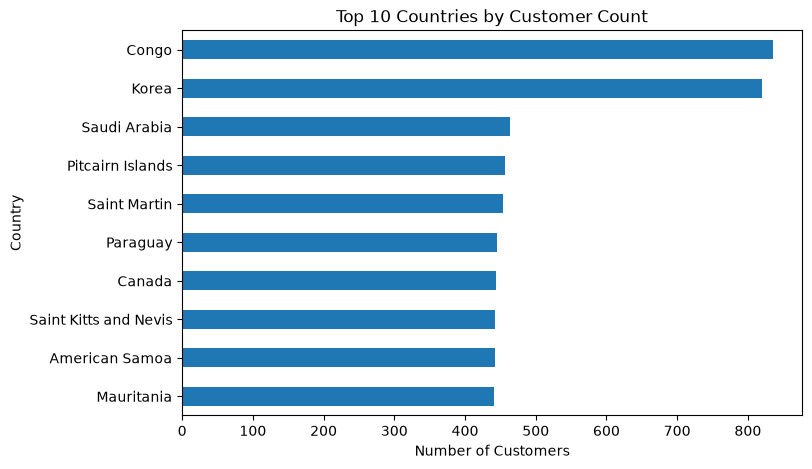

In [54]:
country_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Countries by Customer Count"
)

plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.show()

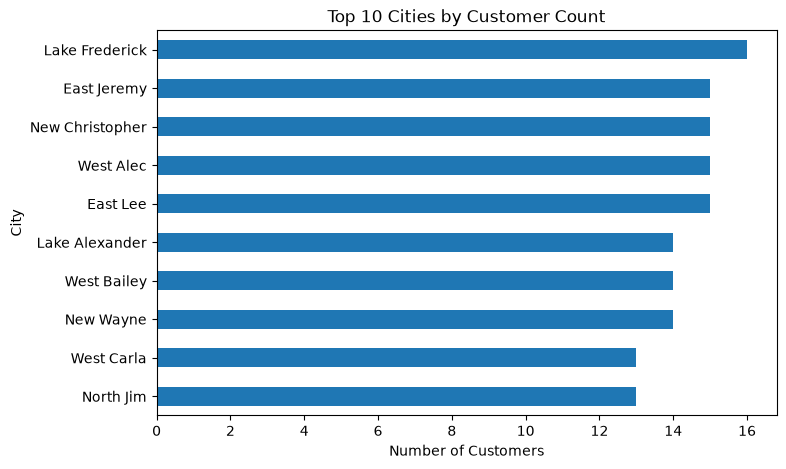

In [55]:
city_counts = df["City"].value_counts().head(10)

city_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Cities by Customer Count"
)

plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.show()

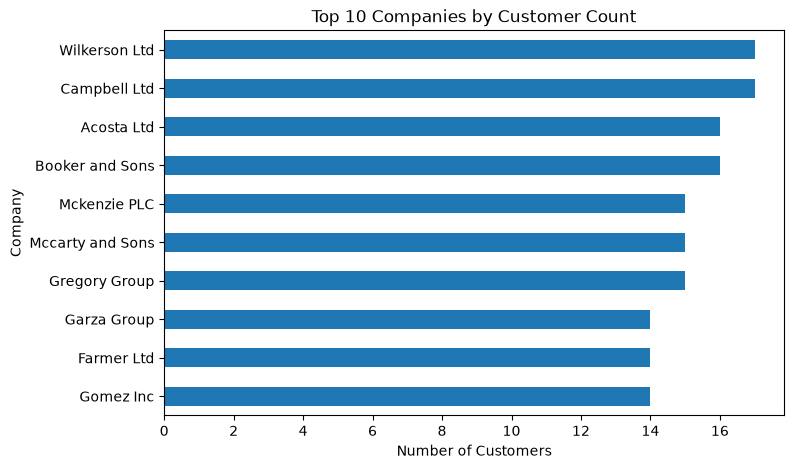

In [56]:
company_counts = df["Company"].value_counts().head(10)

company_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Companies by Customer Count"
)

plt.xlabel("Number of Customers")
plt.ylabel("Company")
plt.show()

# Subscription Trends

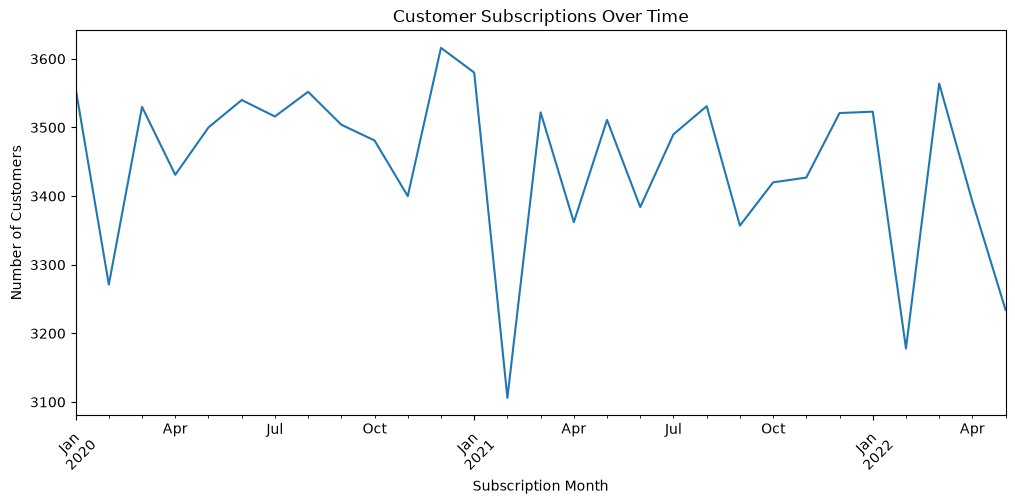

In [57]:
df["Subscription Date"] = pd.to_datetime(
    df["Subscription Date"],
    errors="coerce"
)

subscription_timeline = (
    df["Subscription Date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

subscription_timeline.plot(
    figsize=(12, 5),
    title="Customer Subscriptions Over Time"
)

plt.xlabel("Subscription Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

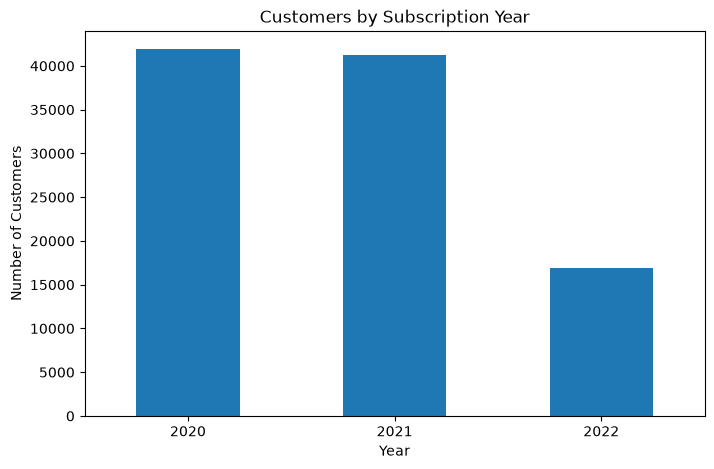

In [58]:
customers_per_year = (
    df["Subscription Date"]
    .dropna()
    .dt.year
    .value_counts()
    .sort_index()
)

customers_per_year.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customers by Subscription Year"
)

plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [59]:
customers_per_month = (
    df["Subscription Date"]
    .dt.month
    .value_counts()
    .sort_index()
)

customers_per_month.index = pd.to_datetime(
    customers_per_month.index,
    format="%m"
).month_name()

display(customers_per_month)

Subscription Date
January      10660
February      9555
March        10616
April        10185
May          10245
June          6924
July          7006
August        7083
September     6861
October       6901
November      6827
December      7137
Name: count, dtype: int64

# Data Quality

In [60]:
duplicate_emails = df[
    df["Email"].duplicated(keep=False)
].sort_values("Email")

print(f"Duplicate emails: {duplicate_emails['Email'].nunique():,}")

display(duplicate_emails.groupby(['Email'])['Index'].count())

Duplicate emails: 5


Email
imitchell@church.com     2
julia03@briggs.com       2
kwalls@white.com         2
ushields@saunders.com    2
vgeorge@mendoza.com      2
Name: Index, dtype: int64

In [61]:
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

invalid_email_mask = (
    df["Email"].notna()
    & ~df["Email"].str.match(email_pattern, na=False)
)

invalid_emails = df[invalid_email_mask]

print(f"Invalid emails: {len(invalid_emails):,}")

display(invalid_emails[["Customer Id", "Email"]].head(20))

Invalid emails: 0


,Customer Id,Email


In [62]:
for column in ["Country", "City", "Company"]:
    print(f"\n{column}")
    print(f"Unique values: {df[column].nunique():,}")
    print(df[column].dropna().value_counts().head(10))



Country
Unique values: 243
Country
Congo                    835
Korea                    820
Saudi Arabia             463
Pitcairn Islands         456
Saint Martin             453
Paraguay                 445
Canada                   444
American Samoa           443
Saint Kitts and Nevis    443
Mauritania               441
Name: count, dtype: int64

City
Unique values: 49,154
City
Lake Frederick     16
East Lee           15
West Alec          15
New Christopher    15
East Jeremy        15
New Wayne          14
West Bailey        14
Lake Alexander     14
North Jim          13
West Carla         13
Name: count, dtype: int64

Company
Unique values: 71,994
Company
Campbell Ltd        17
Wilkerson Ltd       17
Booker and Sons     16
Acosta Ltd          16
Gregory Group       15
Mccarty and Sons    15
Mckenzie PLC        15
Gomez Inc           14
Farmer Ltd          14
Garza Group         14
Name: count, dtype: int64


In [63]:
string_columns = [
    "Customer Id",
    "First Name",
    "Last Name",
    "Company",
    "City",
    "Country",
    "Email"
]

for column in string_columns:
    whitespace_count = (
        df[column]
        .astype("string")
        .str.strip()
        .ne(df[column].astype("string"))
        .sum()
    )

    print(f"{column}: {whitespace_count:,} values with whitespace issues")

Customer Id: 0 values with whitespace issues
First Name: 0 values with whitespace issues
Last Name: 0 values with whitespace issues
Company: 0 values with whitespace issues
City: 0 values with whitespace issues
Country: 0 values with whitespace issues
Email: 0 values with whitespace issues


# Key Insight

## Geographic Concentration

In [64]:
country_counts = df["Country"].value_counts()

top_5_country_percentage = (
    country_counts.head(5).sum()
    / len(df)
    * 100
)

print(
    f"Top 5 countries represent "
    f"{top_5_country_percentage:.2f}% of customers."
)

Top 5 countries represent 3.03% of customers.


## Subscription Period

In [65]:
subscription_dates = df["Subscription Date"].dropna()

print(f"Earliest subscription: {subscription_dates.min().date()}")
print(f"Latest subscription:   {subscription_dates.max().date()}")

Earliest subscription: 2020-01-01
Latest subscription:   2022-05-29


## Subscription Growth

In [66]:
yearly = (
    subscription_dates
    .dt.year
    .value_counts()
    .sort_index()
)

yearly_growth = yearly.pct_change() * 100

display(
    pd.DataFrame({
        "customers": yearly,
        "growth_percentage": yearly_growth.round(2)
    })
)

,customers,growth_percentage
Subscription Date,,
2020,41898,NaN
2021,41211,-1.64
2022,16891,-59.01


## Data quality summary

In [67]:
quality_summary = {
    "total_rows": len(df),
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_customer_ids": df["Customer Id"].duplicated().sum(),
    "duplicate_emails": df["Email"].duplicated().sum(),
    "invalid_emails": invalid_email_mask.sum(),
    "rows_with_missing_values": df.isna().any(axis=1).sum(),
}

display(pd.Series(quality_summary, name="count"))

total_rows                  100000
duplicate_rows                   0
duplicate_customer_ids           0
duplicate_emails                 5
invalid_emails                   0
rows_with_missing_values         0
Name: count, dtype: int64